In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d, griddata
from itertools import product
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
import glob

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution
pd.set_option('display.max_rows', 200)

In [2]:
cmsCutflow = pd.read_pickle('../../CMS-EXO-20-004/AuxInfo/CMS-EXO-20-004-data/DMsimp_S3D_uR_CF_Monojet.pcl')

In [3]:
cmsCutflow.columns

Index(['$m_{med}$', '$m_{DM}$', '$\lambda$', 'Mode', 'Data-takingperiod',
       'Fullsample', 'Triggeremulation', '$p_{T}^{miss}>250$GeV',
       '$p_{T}^{miss}$qualityfilters', 'Electronveto', 'Muonveto', 'Tauveto',
       'Bjetveto', 'Photonveto', '$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad',
       '$\Delta p_{T}^{miss}$ (PF-Cal)$<0.5$ rad',
       'LeadingAK4jet$p_{T}>100$GeV', 'LeadingAK4jet$\eta<2.4$',
       'LeadingAK4jetenergyfractions', 'Mono-Voverlapremoval',
       'HCALmitigation(jets)', 'HCALmitigation($\phi^{miss}$)',
       '$\Delta \phi (\mathrm{PF}_\mathrm{Charged})<2.0$ rad', 'Coupling'],
      dtype='object')

In [9]:
cmsCutflow[((cmsCutflow['$m_{med}$']==300)|(cmsCutflow['$m_{med}$']==500))
            &(cmsCutflow['$m_{DM}$']==200)&(cmsCutflow['Data-takingperiod']==2017)&(cmsCutflow['Mode']=='DM+2QCDjets')].T

,70,101
$m_{med}$,300.0,500.0
$m_{DM}$,200.0,200.0
$\lambda$,1.0,1.0
Mode,DM+2QCDjets,DM+2QCDjets
Data-takingperiod,2017,2017
Fullsample,1.0,1.0
Triggeremulation,0.60136,0.7855
$p_{T}^{miss}>250$GeV,0.21455,0.39029
$p_{T}^{miss}$qualityfilters,0.21423,0.38955
Electronveto,0.21355,0.38846


In [ ]:
cmsCutflow[((cmsCutflow['$m_{med}$']==300)|(cmsCutflow['$m_{med}$']==500))
            &(cmsCutflow['$m_{DM}$']==200)&(cmsCutflow['Data-takingperiod']==2017)&(cmsCutflow['Mode']=='DM+QCDjets')].T

,32,172
$m_{med}$,500.0,300.0
$m_{DM}$,200.0,200.0
$\lambda$,1.0,1.0
Mode,DM+QCDjets,DM+QCDjets
Data-takingperiod,2017,2017
Fullsample,1.0,1.0
Triggeremulation,0.86888,0.51669
$p_{T}^{miss}>250$GeV,0.54465,0.096462
$p_{T}^{miss}$qualityfilters,0.54371,0.096312
Electronveto,0.54094,0.09546


In [11]:
pd.read_pickle('/home/ramos/MG5/dmsimpt_pptoxdxd_0j1j/Events/run_01/ys3u1_300_200_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,104929665.444946,110891578.254318,139508759.739304
bin_250.0_280.0_ErrorPlus,11185539.919909,11498921.000215,12897589.400422
bin_250.0_280.0_ErrorMinus,11185539.919909,11498921.000215,12897589.400422
bin_280.0_310.0,67965806.02684,84659161.893082,100160135.197449
bin_280.0_310.0_ErrorPlus,9002290.925656,10047194.053277,10928366.694269
bin_280.0_310.0_ErrorMinus,9002290.925656,10047194.053277,10928366.694269
bin_310.0_340.0,51272450.160599,67965806.02684,57234362.969971
bin_310.0_340.0_ErrorPlus,7818975.346941,9002290.925656,8261068.716902


In [12]:
pd.read_pickle('/home/ramos/MG5/dmsimpt_pptoxdxd_no_onshell_match/Events/run_09/combined_nocut_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,164579116.229176,185747528.51665,212001540.028691
bin_250.0_280.0_ErrorPlus,5388650.393635,5711867.232206,6119187.709026
bin_250.0_280.0_ErrorMinus,5388650.393635,5711867.232206,6119187.709026
bin_280.0_310.0,127159010.337114,151708044.999123,165378620.269775
bin_280.0_310.0_ErrorPlus,4729498.144432,5175489.269273,5402673.865543
bin_280.0_310.0_ErrorMinus,4729498.144432,5175489.269273,5402673.865543
bin_310.0_340.0,96008624.071598,104173974.164128,121242206.609249
bin_310.0_340.0_ErrorPlus,4114204.047784,4287506.887081,4615981.699605


In [ ]:
pd.read_pickle('/home/ramos/MG5/dmsimpt_pptoxdxd_no_onshell_match/Events/run_08/combined_nocut_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,295343769.949675,341215692.444086,406043157.267809
bin_250.0_280.0_ErrorPlus,17592253.520131,18916401.987816,20666268.990271
bin_250.0_280.0_ErrorMinus,17592253.520131,18916401.987816,20666268.990271
bin_280.0_310.0,239858801.939821,260091117.148018,315200650.357103
bin_280.0_310.0_ErrorPlus,15888234.321684,16543383.850442,18134284.667037
bin_280.0_310.0_ErrorMinus,15888234.321684,16543383.850442,18134284.667037
bin_310.0_340.0,162173916.353846,193416130.18136,232994616.645432
bin_310.0_340.0_ErrorPlus,13074953.511403,14249700.671476,15605640.427066


In [3]:
# cutflow = pd.read_pickle('/home/ramos/scanResults_S3D_uR_1j_CMS_default.pcl')
cutflow = pd.read_pickle('/home/ramos/scanResults_S3D_uR_1j_CMS_default.pcl')

In [4]:
cutflow.T

,0,1,2,3,4,5,6,7,8,9,...,134,135,136,137,138,139,140,141,142,143
Coupling,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,...,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel
Mode,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,...,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets
$m_{med}$,100.0,100.0,100.0,100.0,100.0,100.0,300.0,300.0,300.0,300.0,...,2000.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0
$m_{DM}$,1.0,1.0,1.0,75.0,75.0,75.0,1.0,1.0,1.0,200.0,...,500.0,1.0,1.0,1.0,200.0,200.0,200.0,350.0,350.0,350.0
Data-takingperiod,2018,2017,2016,2018,2017,2016,2018,2017,2016,2018,...,2016,2018,2017,2016,2018,2017,2016,2018,2017,2016
Luminosity (1/fb),59.7,41.5,36.0,59.7,41.5,36.0,59.7,41.5,36.0,59.7,...,36.0,59.7,41.5,36.0,59.7,41.5,36.0,59.7,41.5,36.0
bin_250.0_280.0,94376.245916,64715.140057,51232.819211,41622.080187,41622.080187,40397.901358,17539.007472,16174.104167,12079.394251,6517.876615,...,3.307387,7.217125,5.089533,4.588923,6.351267,5.608578,5.01955,4.442818,4.159234,3.686594
bin_250.0_280.0_ErrorPlus,15952.497156,13209.922648,11753.614818,7138.127863,7138.127863,7032.371974,1094.053227,1050.620965,907.942871,413.885579,...,0.212169,0.548708,0.460785,0.437537,0.403306,0.378993,0.358539,0.264566,0.255983,0.241
bin_250.0_280.0_ErrorMinus,15952.497156,13209.922648,11753.614818,7138.127863,7138.127863,7032.371974,1094.053227,1050.620965,907.942871,413.885579,...,0.212169,0.548708,0.460785,0.437537,0.403306,0.378993,0.358539,0.264566,0.255983,0.241
bin_280.0_310.0,56625.74755,32357.570028,59322.211719,31828.649555,22035.218923,25707.75541,10032.039293,9144.852145,9622.568302,4126.236406,...,2.694908,4.296901,4.130031,3.671139,4.96833,4.276861,3.815882,3.733858,3.355745,2.788577


In [9]:
cmsCutflow[(cmsCutflow['$m_{DM}$']==200)&(cmsCutflow['$m_{med}$']==300)].T

,41,70,172
$m_{med}$,300.0,300.0,300.0
$m_{DM}$,200.0,200.0,200.0
$\lambda$,1.0,1.0,1.0
Mode,DM+QCDjets,DM+2QCDjets,DM+QCDjets
Data-takingperiod,2018,2017,2017
Fullsample,1.0,1.0,1.0
Triggeremulation,0.47796,0.60136,0.51669
$p_{T}^{miss}>250$GeV,0.091679,0.21455,0.096462
$p_{T}^{miss}$qualityfilters,0.091578,0.21423,0.096312
Electronveto,0.091039,0.21355,0.09546


In [6]:
cutflow[(cutflow['$m_{DM}$']==200)&(cutflow['$m_{med}$']==500)].T

,15,16,17
Coupling,tchannel,tchannel,tchannel
Mode,DM+QCDjets,DM+QCDjets,DM+QCDjets
$m_{med}$,500.0,500.0,500.0
$m_{DM}$,200.0,200.0,200.0
Data-takingperiod,2018,2017,2016
Luminosity (1/fb),59.7,41.5,36.0
bin_250.0_280.0,4953.119913,4352.741742,3789.887207
bin_250.0_280.0_ErrorPlus,162.945682,152.75129,142.533378
bin_250.0_280.0_ErrorMinus,162.945682,152.75129,142.533378
bin_280.0_310.0,3934.62123,3173.427477,2867.877872


In [10]:
pd.read_pickle('../DMSimp_S3D_uR_1j_test/Events/run_01/ys3u1_300_200_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,497790415.276337,474086109.786987,571537143.465424
bin_250.0_280.0_ErrorPlus,25603576.21872,24986531.899592,27434660.809533
bin_250.0_280.0_ErrorMinus,25603576.21872,24986531.899592,27434660.809533
bin_280.0_310.0,314740500.664139,351613864.758682,376635076.108551
bin_280.0_310.0_ErrorPlus,20358870.544984,21518419.066943,22270898.926728
bin_280.0_310.0_ErrorMinus,20358870.544984,21518419.066943,22270898.926728
bin_310.0_340.0,197535879.077911,227824713.869858,277867136.569595
bin_310.0_340.0_ErrorPlus,16128736.987766,17321192.247255,19129162.569078


In [11]:
pd.read_pickle('../DMSimp_S3D_uR_1j_test/Events/run_02/ys3u1_500_200_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,364053712.944984,427729528.419495,503764362.931252
bin_250.0_280.0_ErrorPlus,9889989.195127,10720071.974662,11633939.62186
bin_250.0_280.0_ErrorMinus,9889989.195127,10720071.974662,11633939.62186
bin_280.0_310.0,289362250.067711,307632104.296684,373457314.386368
bin_280.0_310.0_ErrorPlus,8817267.590713,9091361.204666,10016905.338845
bin_280.0_310.0_ErrorMinus,8817267.590713,9091361.204666,10016905.338845
bin_310.0_340.0,187803354.500771,234284013.053894,264644211.993217
bin_310.0_340.0_ErrorPlus,7103375.244166,7933857.794913,8432265.740854


In [21]:
pd.read_pickle('../DMSimp_S3D_uR_1j_CMS-BPs_v2/Events/run_36/ys3u1_750_550_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,201.376797,258.861377,297.18443
bin_250.0_280.0_ErrorPlus,8.532609,9.674104,10.365497
bin_250.0_280.0_ErrorMinus,8.532609,9.674104,10.365497
bin_280.0_310.0,165.222974,195.592185,244.038309
bin_280.0_310.0_ErrorPlus,7.728805,8.409165,9.393039
bin_280.0_310.0_ErrorMinus,7.728805,8.409165,9.393039
bin_310.0_340.0,135.938377,158.353747,176.069121
bin_310.0_340.0_ErrorPlus,7.010486,7.566435,7.978453


In [22]:
abs(0.3521-0.243947)/0.3521

0.3071655779608066

In [23]:
pd.read_pickle('../DMSimp_S3D_uR_2j_CMS-BPs_sample/Events/run_01/ys3u1_750_550_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,82.329394,93.359592,104.830997
bin_250.0_280.0_ErrorPlus,2.695343,2.872938,3.044015
bin_250.0_280.0_ErrorMinus,2.695343,2.872938,3.044015
bin_280.0_310.0,72.005129,85.064883,98.83057
bin_280.0_310.0_ErrorPlus,2.520684,2.739755,2.958397
bin_280.0_310.0_ErrorMinus,2.520684,2.739755,2.958397
bin_310.0_340.0,57.445269,68.1225,79.682147
bin_310.0_340.0_ErrorPlus,2.254913,2.451782,2.654591


In [24]:
abs(0.32266-0.315838)/0.32266

0.0211429988222897

In [17]:
cmsCutflow[(cmsCutflow['$m_{DM}$']==200)&(cmsCutflow['$m_{med}$']==300)].T

,3
$m_{med}$,300.0
$m_{DM}$,200.0
$\lambda$,1.0
Mode,DM+QCDjets
Data-takingperiod,2017
Fullsample,1.0
Triggeremulation,0.51669
$p_{T}^{miss}>250$GeV,0.096462
$p_{T}^{miss}$qualityfilters,0.096312
Electronveto,0.09546


In [20]:
pd.read_pickle('../DMSimp_S3D_uR_1j_CMS-BPs_v2/Events/run_13/ys3u1_300_200_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,6304.202707,8141.865035,8167.388123
bin_250.0_280.0_ErrorPlus,401.126813,455.856926,456.570876
bin_250.0_280.0_ErrorMinus,401.126813,455.856926,456.570876
bin_280.0_310.0,4849.386698,5461.940807,6048.971828
bin_280.0_310.0_ErrorPlus,351.811488,373.370587,392.922944
bin_280.0_310.0_ErrorMinus,351.811488,373.370587,392.922944
bin_310.0_340.0,3547.709216,4568.632731,4645.201995
bin_310.0_340.0_ErrorPlus,300.912768,341.475643,344.32528


In [25]:
abs(0.0622-0.078455)/0.0622

0.2613344051446945

In [26]:
cmsCutflow[(cmsCutflow['$m_{DM}$']==200)&(cmsCutflow['$m_{med}$']==500)].T

,5
$m_{med}$,500.0
$m_{DM}$,200.0
$\lambda$,1.0
Mode,DM+QCDjets
Data-takingperiod,2017
Fullsample,1.0
Triggeremulation,0.86888
$p_{T}^{miss}>250$GeV,0.54465
$p_{T}^{miss}$qualityfilters,0.54371
Electronveto,0.54094


In [27]:
pd.read_pickle('../DMSimp_S3D_uR_1j_CMS-BPs_v2/Events/run_14/ys3u1_500_200_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,3137.274777,4021.369924,4430.579677
bin_250.0_280.0_ErrorPlus,125.8945,142.533678,149.610045
bin_250.0_280.0_ErrorMinus,125.8945,142.533678,149.610045
bin_280.0_310.0,2601.765717,2854.36433,3511.120725
bin_280.0_310.0_ErrorPlus,114.647496,120.08401,133.1844
bin_280.0_310.0_ErrorMinus,114.647496,120.08401,133.1844
bin_310.0_340.0,2015.736934,2303.699353,2323.907242
bin_310.0_340.0_ErrorPlus,100.913067,107.880606,108.352734


In [28]:
abs(0.39732-0.221907)/0.39732

0.44149048625792814

In [4]:
year = 2017

cutflow = cutflow[cutflow['Data-takingperiod']==year]
cmsCutflow = cmsCutflow[cmsCutflow['Data-takingperiod']==year]

In [5]:
models = []
mCols = ['Mode','$m_{med}$','$m_{DM}$','$\lambda$','Data-takingperiod']
for row in cutflow[mCols].values:
    m = dict(zip(mCols,row.tolist()))
    if m not in models:
        models.append(m)
print('%i models loaded' %len(models))

48 models loaded


In [6]:
parameters = {label : list(set([m[label] for m in models])) for label in mCols}
for k,v in parameters.items():
    if len(v) == 1:
        parameters[k] = v[0]
print(parameters)

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in parameters.items() if k not in ['$m_{med}$','$m_{DM}$']])
print(textstr)

{'Mode': 'DM+QCDjets', '$m_{med}$': [1600.0, 100.0, 1000.0, 1800.0, 300.0, 750.0, 1200.0, 2000.0, 500.0, 1400.0, 2200.0], '$m_{DM}$': [800.0, 1.0, 900.0, 550.0, 200.0, 650.0, 75.0, 750.0, 400.0, 500.0, 600.0, 700.0, 350.0], '$\\lambda$': 1.0, 'Data-takingperiod': 2017}
Mode = DM+QCDjets
$\lambda$ = 1.0
Data-takingperiod = 2017


In [7]:
keys = list(cmsCutflow[mCols].columns.values)
i1 = cutflow.set_index(keys).index
i2 = cmsCutflow.set_index(keys).index
cutflow = cutflow[i1.isin(i2)]
cmsCutflow = cmsCutflow[i2.isin(i1)]
print(len(cutflow),len(cmsCutflow))

46 46


In [8]:
cutflow.sort_values(['$m_{med}$','$m_{DM}$'],inplace=True,
                ascending=[True,True],ignore_index=True)  
cmsCutflow.sort_values(['$m_{med}$','$m_{DM}$'],inplace=True,
                ascending=[True,True],ignore_index=True)

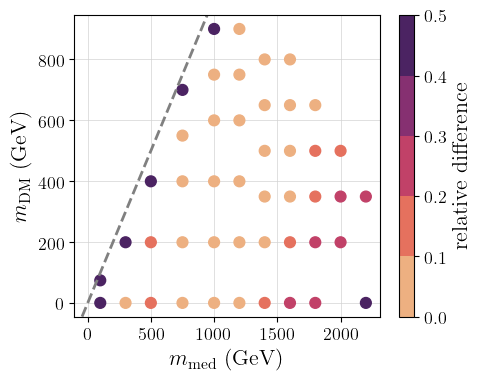

In [9]:
mmed = cutflow['$m_{med}$']
mDM = cutflow['$m_{DM}$']

relDiff = np.abs(cmsCutflow['HCALmitigation($\\phi^{miss}$)'] - cutflow['HCALmitigation($\\phi^{miss}$)'])/np.array(cmsCutflow['HCALmitigation($\\phi^{miss}$)'])

plt.scatter(x=mmed, y=mDM, c=relDiff, cmap=plt.get_cmap('flare', 5), vmin=0., vmax=0.5, s=60)
cbar = plt.colorbar(label=r'relative difference')
cbar.set_ticks([0.,0.1,0.2,0.3,0.4,0.5])
plt.axline((1, 1), slope=1, linestyle='--', color='gray')

plt.xlabel(r'$m_{\rm med}$ (GeV)')
plt.ylabel(r'$m_{\rm DM}$ (GeV)')

plt.tight_layout()
plt.savefig('relDiff_eff_1j_default.png')

plt.show()

In [39]:
cutflow[(cutflow['$m_{med}$']==1000)&(cutflow['$m_{DM}$']==900)].T

,17
Coupling,tchannel
Mode,DM+QCDjets
$m_{med}$,1000.0
$m_{DM}$,900.0
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,7.086368
bin_250.0_280.0_ErrorPlus,0.254059
bin_250.0_280.0_ErrorMinus,0.254059
bin_280.0_310.0,6.02068


In [41]:
cmsCutflow[(cutflow['$m_{med}$']==100)&(cutflow['$m_{DM}$']==1)].T

,0
$m_{med}$,100.0
$m_{DM}$,1.0
$\lambda$,1.0
Mode,DM+QCDjets
Data-takingperiod,2017
Fullsample,1.0
Triggeremulation,0.047334
$p_{T}^{miss}>250$GeV,0.003092
$p_{T}^{miss}$qualityfilters,0.003092
Electronveto,0.003073


In [18]:
cutflow[(cutflow['$m_{med}$']==1800)&(cutflow['$m_{DM}$']==1)].T

,36
Coupling,tchannel
Mode,DM+QCDjets
$m_{med}$,1800.0
$m_{DM}$,1.0
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,7.812074
bin_250.0_280.0_ErrorPlus,0.36424
bin_250.0_280.0_ErrorMinus,0.36424
bin_280.0_310.0,6.470435
